# **1. 호텔 예약 수요 데이터셋**
호텔 예약 수요 데이터셋은 일반적으로 호텔 예약에 대한 수요 패턴을 분석하기 위한 데이터셋입니다. 이 데이터셋은 예약 취소, 체크인 날짜, 고객 유형, 체류 기간, 객실 유형, 예약 경로 등 다양한 요소를 포함하며, 주로 예약 트렌드 분석, 고객 행동 예측, 수요 예측 등에 사용됩니다.

# **2. 데이터셋 컬럼 설명**

```
hotel: 호텔 유형 (Resort Hotel, City Hotel)
is_canceled: 예약 취소 여부 (0: 예약 유지, 1: 예약 취소)
lead_time: 예약과 실제 체크인 사이의 기간(일 단위)
arrival_date_year: 도착 연도
arrival_date_month: 도착 월
arrival_date_week_number: 해당 연도의 주
arrival_date_day_of_month: 도착 일
stays_in_weekend_nights: 주말(토, 일) 동안의 숙박일 수
stays_in_week_nights: 주중(월~금) 동안의 숙박일 수
adults: 성인 투숙객 수
children: 어린이 투숙객 수
babies: 유아 투숙객 수
meal: 예약된 식사 유형
country: 고객의 국가
market_segment: 예약 시장 세그먼트
distribution_channel: 예약 채널 (예: 온라인, 오프라인)
is_repeated_guest: 재방문 여부
previous_cancellations: 이전 예약 취소 횟수
reserved_room_type: 예약된 객실 유형
assigned_room_type: 실제 배정된 객실 유형
booking_changes: 예약 변경 횟수
deposit_type: 보증금 유형 (No Deposit, Non Refund, Refundable)
days_in_waiting_list: 대기자 명단에 있었던 일 수
customer_type: 고객 유형 (예: Transient, Group)
adr: 평균 일일 요금 (유로)
required_car_parking_spaces: 주차 공간 요구 수
total_of_special_requests: 특별 요청 수
reservation_status: 예약 상태 (Check-Out, Canceled, No-Show)
reservation_status_date: 예약 상태가 마지막으로 업데이트된 날짜

```


# **3. 데이터 전처리 및 EDA**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "./data/hotel_bookings.csv"
hotel_raw = pd.read_csv(DATA_PATH)
hotel_raw.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
hotel_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
hotel_raw.describe(include='str').T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


In [5]:
print('행/열 크기: ', hotel_raw.shape)
print('타킷 분포')
print(hotel_raw['is_canceled'].value_counts())
print('타킷 비율')
print(hotel_raw['is_canceled'].value_counts(normalize=True).round(2))

행/열 크기:  (119390, 32)
타킷 분포
is_canceled
0    75166
1    44224
Name: count, dtype: int64
타킷 비율
is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64


# **4. EDA**

In [6]:
missing_summary = pd.DataFrame({'missing_count': hotel_raw.isna().sum(),
                                'missing_ratio': hotel_raw.isna().mean()}).sort_values('missing_count', ascending=False)
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_ratio
company,112593,0.943069
agent,16340,0.136862
country,488,0.004087
children,4,0.000034


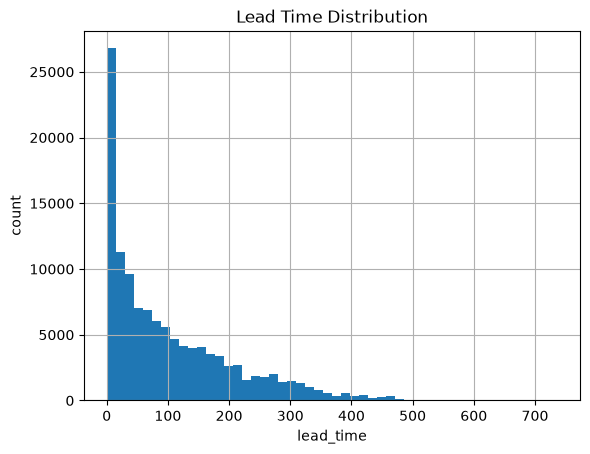

In [7]:
# 최소값부터 최대값까지를 50개의 구간으로 나눈 다음, 각 구간에 데이터가 몇 개 들어있는지 막대로 확인

hotel_raw['lead_time'].hist(bins=50)
plt.title('Lead Time Distribution')
plt.xlabel('lead_time')
plt.ylabel('count')
plt.show()


In [8]:
cancel_by_hotel = hotel_raw.groupby('hotel')['is_canceled'].mean().sort_values(ascending=False)
cancel_by_hotel

hotel
City Hotel      0.417270
Resort Hotel    0.277634
Name: is_canceled, dtype: float64

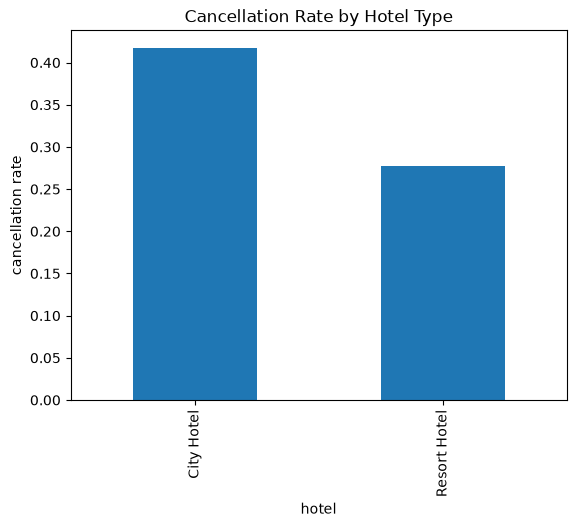

In [9]:
cancel_by_hotel.plot(kind='bar')
plt.title('Cancellation Rate by Hotel Type')
plt.ylabel('cancellation rate')
plt.show()

In [10]:
hotel_raw['arrival_date_month']

0           July
1           July
2           July
3           July
4           July
           ...  
119385    August
119386    August
119387    August
119388    August
119389    August
Name: arrival_date_month, Length: 119390, dtype: str

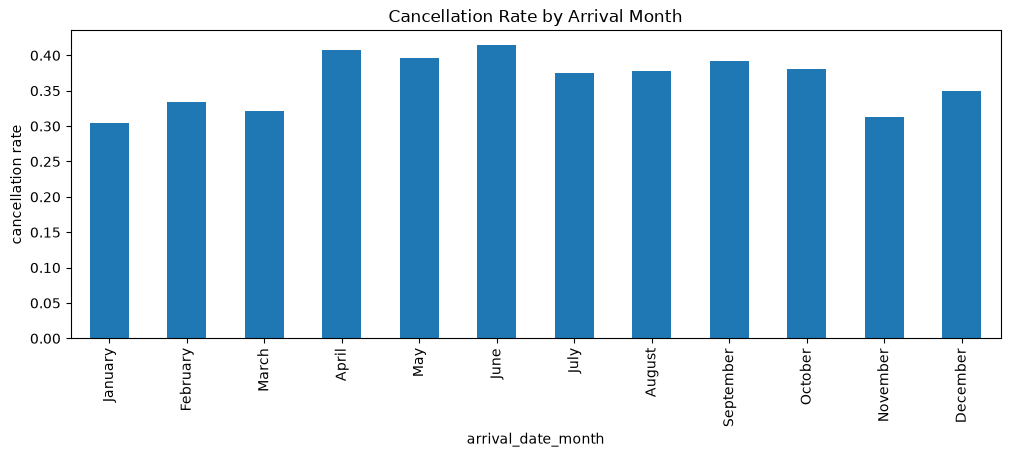

In [11]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

cancel_by_month = hotel_raw.groupby('arrival_date_month')['is_canceled'].mean().reindex(month_order)
cancel_by_month.plot(kind='bar', figsize=(12, 4))
plt.title('Cancellation Rate by Arrival Month')
plt.ylabel('cancellation rate')
plt.show()

In [12]:
hotel_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [13]:
def add_basic_features(df):
    df = df.copy()
    df['children'] = df['children'].fillna(0)
    df['people'] = df['adults'] + df['children'] + df['babies'] # 인원수
    df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

    season_map = {
        'December': 'winter', 'January': 'winter', 'February': 'winter',
        'March': 'spring', 'April': 'spring', 'May': 'spring',
        'June': 'summer', 'July': 'summer', 'August': 'summer',
        'September': 'fall', 'October': 'fall', 'November': 'fall',
    }
    df['season'] = df['arrival_date_month'].map(season_map)
    previous_total = df['previous_cancellations'] + df['previous_bookings_not_canceled']
    # 이전 취소율: 분모가 0보다 크면 캔슬수 / 전체, 기록이 없으면 -1 처리
    df['previous_cancel_rate'] = np.where(
        previous_total > 0, df['previous_cancellations'] / previous_total, -1)

    return df

In [14]:
hotel = add_basic_features(hotel_raw)

In [15]:
hotel.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [16]:
# people이 0인 데이터는 비정상 데이터로 제거
hotel = hotel[hotel['people'] > 0].copy()

In [17]:
# 실제 예약 시점 예측에 부적절하거나 누수 위험이 큰 컬럼 제거
leakage_or_post_booking_cols = [
    'reservation_status', 'reservation_status_date', 'assigned_room_type'
]

redundant_cols = [
    'adults', 'children', 'babies', 'stay_in_week_nights',
    'arrival_date_month', 'previous_cancellations', 'previous_bookings_not_canceled'
]

cols_to_drop = [col for col in leakage_or_post_booking_cols + redundant_cols if col in hotel.columns]
hotel = hotel.drop(columns=cols_to_drop)
hotel.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,meal,country,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,people,total_nights,season,previous_cancel_rate
0,Resort Hotel,0,342,2015,27,1,0,0,BB,PRT,...,NaN,0,Transient,0.0,0,0,2.0,0,summer,-1.0
1,Resort Hotel,0,737,2015,27,1,0,0,BB,PRT,...,NaN,0,Transient,0.0,0,0,2.0,0,summer,-1.0
2,Resort Hotel,0,7,2015,27,1,0,1,BB,GBR,...,NaN,0,Transient,75.0,0,0,1.0,1,summer,-1.0
3,Resort Hotel,0,13,2015,27,1,0,1,BB,GBR,...,NaN,0,Transient,75.0,0,0,1.0,1,summer,-1.0
4,Resort Hotel,0,14,2015,27,1,0,2,BB,GBR,...,NaN,0,Transient,98.0,0,1,2.0,2,summer,-1.0


In [18]:
hotel.info()

<class 'pandas.DataFrame'>
Index: 119210 entries, 0 to 119389
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   hotel                        119210 non-null  str    
 1   is_canceled                  119210 non-null  int64  
 2   lead_time                    119210 non-null  int64  
 3   arrival_date_year            119210 non-null  int64  
 4   arrival_date_week_number     119210 non-null  int64  
 5   arrival_date_day_of_month    119210 non-null  int64  
 6   stays_in_weekend_nights      119210 non-null  int64  
 7   stays_in_week_nights         119210 non-null  int64  
 8   meal                         119210 non-null  str    
 9   country                      118732 non-null  str    
 10  market_segment               119210 non-null  str    
 11  distribution_channel         119210 non-null  str    
 12  is_repeated_guest            119210 non-null  int64  
 13  reserved_room_t

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X = hotel.drop(columns='is_canceled')
y = hotel['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2026, stratify=y)

In [21]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

(83447, 26) (35763, 26)
is_canceled
0    0.629
1    0.371
Name: proportion, dtype: float64
is_canceled
0    0.629
1    0.371
Name: proportion, dtype: float64


In [22]:
numeric_features = X_train.select_dtypes(include='number').columns.tolist()
print('숫자형 컬럼 수: ', len(numeric_features))
print(numeric_features)
categorical_features = X_train.select_dtypes(exclude='number').columns.tolist()
print('범주형 컬럼 수: ', len(categorical_features))
print(categorical_features)

숫자형 컬럼 수:  17
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'is_repeated_guest', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'people', 'total_nights', 'previous_cancel_rate']
범주형 컬럼 수:  9
['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'season']


In [23]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer



In [24]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# **5.Logistic Regression**
사이킷런의 LogisticRegression은 이진 분류(Binary Classification)와 다중 분류(Multiclass Classification) 문제를 해결하기 위한 머신러닝 알고리즘입니다. 로지스틱 회귀는 선형 모델로, 입력 데이터에 대한 선형 결합을 통해 확률을 예측하고, 이 확률을 로지스틱 함수(시그모이드 함수)를 사용해 이진 또는 다중 클래스에 대한 예측을 수행합니다. 사이킷런의 LogisticRegression은 과적합을 방지하기 위한 규제(Regularization) 기법(penalty)을 지원합니다. 또한, 반복 최적화의 최대 횟수를 max_iter로 설정할 수 있으며, 모델의 성능 평가는 정확도, ROC-AUC 등 다양한 지표를 통해 수행할 수 있습니다. 이 모델은 특히 해석 가능성이 높고, 계산이 효율적이며, 선형적으로 구분 가능한 데이터셋에서 뛰어난 성능을 발휘합니다.

### ※ 규제

규제(Regularization)는 머신러닝 모델이 과적합(Overfitting) 되는 것을 방지하기 위해 사용되는 기법입니다. 과적합은 모델이 학습 데이터에 지나치게 맞춰져서, 새로운 데이터(테스트 데이터)에는 제대로 일반화하지 못하는 현상입니다.

규제는 모델의 복잡도를 줄이고, 불필요한 가중치(Weights)를 작게 만들어 과적합을 방지합니다.

![LogisticRegression](./images/LogisticRegression.png)

In [25]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, RocCurveDisplay)

### 혼동 행렬(Confusion Matrix)
혼동 행렬(Confusion Matrix)은 분류 모델의 성능을 평가하기 위해 사용되는 도구로, 예측 결과와 실제 레이블 간의 관계를 요약하여 나타낸 행렬입니다. 이 행렬은 이진 분류 문제에서 네 가지 값으로 구성됩니다. True Positive (TP), True Negative (TN), False Positive (FP), False Negative (FN). TP와 TN은 모델이 올바르게 예측한 경우를 나타내며, FP와 FN은 모델이 잘못 예측한 경우를 나타냅니다. 이를 통해 분류 모델의 정확도(Accuracy), 정밀도(Precision), 재현율(Recall), F1 점수와 같은 다양한 성능 지표를 계산할 수 있습니다. 혼동 행렬은 특히 클래스 간 불균형이 있는 데이터에서 모델의 예측 성능을 구체적으로 분석할 때 유용합니다.



![혼동행렬](./images/혼동행렬.png)

- True Positive (TP)
    - 실제값이 양성이고, 모델도 양성으로 올바르게 예측한 경우
    - 예: 실제로 스팸 메일이고, 모델이 스팸 메일로 예측
- True Negative (TN)
    - 실제값이 음성이고, 모델도 음성으로 올바르게 예측한 경우
    - 예: 실제로 정상 메일이고, 모델이 정상 메일로 예측
- False Positive (FP)
    - 실제값은 음성이지만, 모델이 양성으로 잘못 예측한 경우
    - 예: 정상 메일을 스팸으로 잘못 예측
- False Negative (FN)
    - 실제값은 양성이지만, 모델이 음성으로 잘못 예측한 경우
    - 예: 스팸 메일을 정상 메일로 잘못 예측



### ※ 혼동 행렬로 계산할 수 있는 지표

![혼동행렬지표](./images/혼동행렬지표.png)

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [29]:
models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=2026, n_jobs=-1),
    'LogisticRegression': LogisticRegression(max_iter=2000)
}

### ※ ROC AUC Score

ROC AUC Score(Receiver Operating Characteristic - Area Under the Curve)는 이진 분류 모델의 성능을 평가하는 지표로, 분류기의 예측 능력을 직관적으로 나타냅니다. ROC 곡선은 FPR(거짓 양성 비율)과 TPR(참 양성 비율)을 축으로 하여 다양한 임계값에서 모델의 성능을 시각화한 곡선입니다. AUC(Area Under the Curve)는 이 곡선 아래의 면적을 나타내며, 값이 1에 가까울수록 완벽한 분류 성능을 의미하고, 0.5에 가까울수록 랜덤 추측에 가까운 성능을 나타냅니다. 따라서 ROC AUC Score는 모델의 분류 성능이 얼마나 좋은지를 평가하는 데 중요한 역할을 합니다.

1. ROC Curve

ROC 곡선은 이진 분류 모델의 성능을 평가하기 위해 사용하는 곡선으로, 모델의 민감도(참 양성 비율, TPR)와 특이도(참 음성 비율, TNR)의 반대인 거짓 양성 비율(FPR)의 관계를 시각화한 그래프입니다.
![ROC곡선](./images/ROC곡선.png)

2. AUC (Area Under the Curve)

AUC는 ROC 곡선 아래의 면적을 나타내며, 이진 분류기의 성능을 하나의 숫자로 나타내는 지표입니다. AUC는 다음을 의미합니다:

    - AUC = 1: 완벽한 분류기
    - AUC = 0.5: 랜덤 추측 수준
    - AUC < 0.5: 모델 성능이 무작위 추측보다 나쁨
>수학적으로 AUC는 양성 클래스와 음성 클래스의 예측 점수를 비교해 양성 클래스가 더 높은 점수를 받을 확률을 나타냅니다.

In [30]:
results = []
fitted_models = {}

for name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    if hasattr(clf.named_steps['model'], 'predict_proba'):
        proba = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)
    else:
        proba = None
        auc = np.nan

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1-score': f1_score(y_test, pred, zero_division=0),
        'roc_auc': auc
    })

    fitted_models[name] = clf

In [31]:
result_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
result_df

,model,accuracy,precision,recall,f1-score,roc_auc
0,RandomForest,0.891508,0.887219,0.810407,0.847076,0.956990
1,LogisticRegression,0.809048,0.801670,0.644419,0.714495,0.887215


### 상세 평가
- 사용 모델: LogisticRegression, RandomForestClassifier
- 평가 지표
  - accuracy: 전체 중 맞힌 비율
  - precision: 예약 취소라고 예측한 것 중 실제 예약 취소인 비율
  - recall: 실제 예약 취소 중 모델이 예약 취소라고 잡아낸 비율
  - f1-score: precision과 recall의 균형 지표
  - roc-auc: 임계값 변화에 따른 전반적인 분류 성능
- 예약 취소 예측에서는 단순 정확도보다 recall, precision, f1-score, roc-auc를 함께 봐야함
- 예약 취소 고객을 최대한 놓치지 않는 것이 중요하면 recall을 더 중요하게 보면 됨
- 불필요한 객실 확보나 과도한 오버부팅을 줄이는 것이 중요하면 precision도 중요

In [32]:
best_model_name = result_df.iloc[0]['model']
print('Best Model: ', best_model_name)
best_model = fitted_models[best_model_name]

best_pred = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)[:, 1]
print('Confusion_matrix')
print(confusion_matrix(y_test, best_pred))

Best Model:  RandomForest
Confusion_matrix
[[21137  1366]
 [ 2514 10746]]


In [ ]:
# 예) 고양이 800개 f1-score 0.9, 강아지 150개 f1-score 0.8, 토끼 50개 f1-score 0.4

# macro avg: 각 클래스를 똑같이 중요하게 생각
# 0.9 + 0.8 + 0.4 / 3 = 0.7
# 토끼처럼 데이터가 적은 클래스의 성능이 나쁘면 macro avg가 크게 떨어짐
# 불균형 데이터에서 중요 > 소수 클래스까지 모델이 잘 분류하는지 확인하기 좋음

# weighted avg: 데이터가 많은 클래스를 더 중요하게 생각
# 0.9*800 + 0.8*150 + 0.4*50 / 1000 = 0.86 > 데이터가 가장 많은 고양이의 f1-score가 높기 때문

print('classification Report')
print(classification_report(y_test, best_pred))

classification Report
              precision    recall  f1-score   support

           0       0.89      0.94      0.92     22503
           1       0.89      0.81      0.85     13260

    accuracy                           0.89     35763
   macro avg       0.89      0.87      0.88     35763
weighted avg       0.89      0.89      0.89     35763



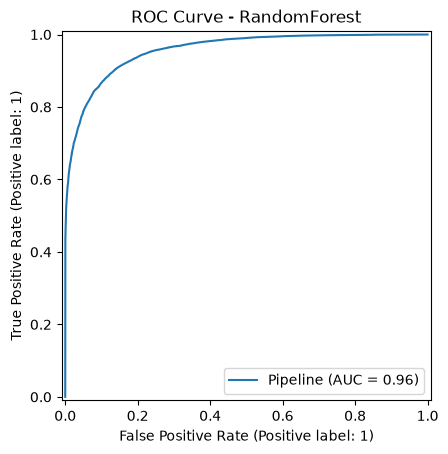

In [36]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f'ROC Curve - {best_model_name}')
plt.show()

### 예측 임계값 조정
- 기본적으로 분류 모델은 보통 확률이 0.5이상이면 1로 예측함
- 실무에서는 0.5가 항상 최선은 아님
  - 임계값을 낮추면 예약 취소라고 예측하는 대상이 늘어남
  - 임계값을 높이면 정말 예약 취소 가능성이 높은 대상만 예약 취소라고 예측
- 예) 예약 취소 가능 고객에게 사전 확인 문자를 보내는 목적 > recall을 높이는 방향이 좋을 수 있음

In [37]:
threshold_table = []

for threshold in np.arange(0.3, 0.71, 0.05):
    threshold_pred = (best_proba >= threshold).astype(int)
    threshold_table.append({
        'threshold': round(threshold, 2),
        'precision': precision_score(y_test, threshold_pred, zero_division=0),
        'recall': recall_score(y_test, threshold_pred, zero_division=0),
        'f1-score': f1_score(y_test, threshold_pred, zero_division=0)
    })

pd.DataFrame(threshold_table)

,threshold,precision,recall,f1-score
0,0.30,0.771503,0.917949,0.838379
1,0.35,0.806964,0.893137,0.847867
2,0.40,0.836747,0.865837,0.851043
3,0.45,0.865005,0.840347,0.852498
4,0.50,0.885987,0.811086,0.846884
5,0.55,0.906958,0.778507,0.837838
6,0.60,0.926020,0.741026,0.823258
7,0.65,0.942742,0.705279,0.806903
8,0.70,0.959271,0.662519,0.783745


In [38]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [39]:
# 교차검증: 데이터를 여러 조각으로 나누고, 학습과 검증을 여러 번 반복해서 평균 성능을 보는 방법
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)
cv_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, random_state=2026, n_jobs=-1))
])
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_result = cross_validate(cv_model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
cv_summary = pd.DataFrame({
    metric: [cv_result[f'test_{metric}'].mean(),
             cv_result[f'test_{metric}'].std()] for metric in scoring}, index=['mean', 'std']
)

cv_summary

,accuracy,precision,recall,f1,roc_auc
mean,0.894262,0.892918,0.812235,0.850657,0.959480
std,0.002938,0.004891,0.005486,0.004270,0.000883


### 교차 검증으로 모델 안정성 확인

- 평균 성능이 높고 표준편차가 작으면 비교적 안정적인 모델
- 표준편차가 크면 데이터 분할에 따라 성능이 많이 흔들린다는 뜻
- 시간 흐름이 중요한 데이터에서는 StratifiedKFold 대신 시간 기준 검증을 고려해야 함